 # Exposition aux conflits armés et dépenses militaires



 Ce notebook construit un panel **pays-année** combinant trois sources :



 - **SIPRI** : dépenses militaires par pays et par année (fichier Excel) ;

 - **UCDP** : conflits armés dans le monde, avec leurs belligérants et leur intensité (fichier CSV) ;

 - **CShapes** : frontières historiques et coordonnées des capitales (fichier géographique).



 L'objectif est de mesurer, pour chaque pays et chaque année, sa **distance au conflit armé le plus proche**

 dont il n'est pas partie prenante, puis de regarder si les épisodes où un pays devient brusquement

 « exposé » à une guerre proche (à moins de 1 000 km) s'accompagnent d'une hausse de ses dépenses

 militaires (étude d'événements + tests de robustesse), avec une application au cas de l'Ukraine (2022).



 **Sorties produites** : les tables intermédiaires dans `../data/processed/`, les figures dans `../figures/`.



 ## 0. Installation et imports

In [1]:
# Dépendances : voir requirements.txt à la racine du dépôt.
# pip install -r requirements.txt




In [2]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Patch
from shapely.geometry import Point
import country_converter as coco

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../figures")
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)



 ## 1. Chargement des données brutes



 Inventaire du dossier de données brutes, puis chargement du fichier UCDP (CSV) et du classeur SIPRI (Excel).



In [3]:
for f in sorted(RAW.iterdir()):
    print(f.name)



CShapes-2.0.geojson
SIPRI-Milex-data-1949-2025_v1.2.xlsx
SOURCES.txt
UcdpPrioConflict_v26_1.csv


In [4]:
csv_files = list(RAW.glob("*.csv"))
xlsx_files = list(RAW.glob("*.xlsx"))
print("CSV trouvés :", [f.name for f in csv_files])
print("Excel trouvés :", [f.name for f in xlsx_files])

ucdp = pd.read_csv(csv_files[0])
print("\nUCDP :", ucdp.shape)
print(ucdp.columns.tolist())

xl = pd.ExcelFile(xlsx_files[0])
print("\nSIPRI, onglets :", xl.sheet_names)



CSV trouvés : ['UcdpPrioConflict_v26_1.csv']
Excel trouvés : ['SIPRI-Milex-data-1949-2025_v1.2.xlsx']

UCDP : (2816, 28)
['conflict_id', 'location', 'side_a', 'side_a_id', 'side_a_2nd', 'side_b', 'side_b_id', 'side_b_2nd', 'incompatibility', 'territory_name', 'year', 'intensity_level', 'cumulative_intensity', 'type_of_conflict', 'start_date', 'start_prec', 'start_date2', 'start_prec2', 'ep_end', 'ep_end_date', 'ep_end_prec', 'gwno_a', 'gwno_a_2nd', 'gwno_b', 'gwno_b_2nd', 'gwno_loc', 'region', 'version']

SIPRI, onglets : ['Front page', 'Regional totals', 'Local currency financial years', 'Local currency calendar years', 'Constant (2024) US$', 'Current US$', 'Share of GDP', 'Per capita', 'Share of Govt. spending', 'Footnotes']


 ### Colonnes UCDP utilisées dans la suite du notebook

In [5]:
ucdp[["conflict_id", "location", "year", "intensity_level", "type_of_conflict",
      "gwno_loc", "gwno_a", "gwno_b"]].head(10)



,conflict_id,location,year,intensity_level,type_of_conflict,gwno_loc,gwno_a,gwno_b
0,200,Bolivia,1946,2,3,145,145,NaN
1,200,Bolivia,1949,1,3,145,145,NaN
2,200,Bolivia,1952,1,3,145,145,NaN
3,200,Bolivia,1967,1,3,145,145,NaN
4,201,Cambodia (Kampuchea),1946,1,1,811,220,NaN
5,201,Cambodia (Kampuchea),1947,1,1,811,220,NaN
6,201,Cambodia (Kampuchea),1948,1,1,811,220,NaN
7,201,Cambodia (Kampuchea),1949,1,1,811,220,NaN
8,201,Cambodia (Kampuchea),1950,1,1,811,220,NaN
9,201,Cambodia (Kampuchea),1951,1,1,811,220,NaN


 ### Mise en forme de SIPRI (passage au format long)



 Le classeur SIPRI a un en-tête sur plusieurs lignes et une colonne par année : on repère l'onglet

 « Constant » (dépenses à prix constants), on retire les lignes d'agrégats régionaux (qui n'ont aucune

 valeur annuelle renseignée), puis on passe au format long (une ligne par pays et par année).



In [6]:
const_sheet = [s for s in xl.sheet_names if "Constant" in s][0]
print("Onglet retenu :", const_sheet)
pd.read_excel(xl, sheet_name=const_sheet, header=None).head(12)



Onglet retenu : Constant (2024) US$


,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,"Military expenditure by country, in constant (...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Figures are in US $m., at constant 2024 prices...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Figures in blue are SIPRI estimates. Figures i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"""..."" = data unavailable. ""xxx"" = country did ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Country,NaN,Notes,1949,1950,1951,1952,1953,1954,1955,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Algeria,NaN,§4,xxx,xxx,xxx,xxx,xxx,xxx,xxx,...,12771.057022,12094.810558,11599.483834,12513.907107,12222.085137,11395.370277,11022.402088,19281.144486,21811.242555,24128.442879


In [7]:
df = pd.read_excel(xl, sheet_name=const_sheet, header=5)
df = df.rename(columns={"Country": "country"})

year_cols = [c for c in df.columns if str(c).isdigit()]
print("Années :", year_cols[0], "→", year_cols[-1], "(", len(year_cols), "colonnes )")

# Lignes de région / titres : toutes les années vides avant conversion numérique
is_header = df[year_cols].isna().all(axis=1)
print("Lignes retirées (régions, titres) :", df.loc[is_header, "country"].tolist())
df = df.loc[~is_header].copy()

sipri = df.melt(id_vars="country", value_vars=year_cols, var_name="year", value_name="milex_usd_m")
sipri["year"] = sipri["year"].astype(int)
sipri["milex_usd_m"] = pd.to_numeric(sipri["milex_usd_m"], errors="coerce")

print("Pays :", sipri["country"].nunique(), "| observations non manquantes :", sipri.dropna().shape[0])
sipri[sipri["country"] == "France"].tail(8)



Années : 1949 → 2025 ( 77 colonnes )
Lignes retirées (régions, titres) : [nan, 'Africa', 'North Africa', 'sub-Saharan Africa', 'Americas', 'Central America and the Caribbean', 'North America', 'South America', 'Asia & Oceania', 'Oceania', 'South Asia', 'East Asia', 'South East Asia', 'Central Asia', 'Europe', 'Central Europe', 'Eastern Europe', 'Western Europe', 'Middle East']
Pays : 174 | observations non manquantes : 8435


,country,year,milex_usd_m
12148,France,2018,54701.000109
12322,France,2019,56073.561441
12496,France,2020,58039.151684
12670,France,2021,60510.285345
12844,France,2022,60193.327247
13018,France,2023,60793.843584
13192,France,2024,63574.699213
13366,France,2025,64515.088592


 ## 2. Correspondance des pays entre UCDP et SIPRI (codes Gleditsch & Ward)



 UCDP identifie les pays par des codes numériques (`gwno`, convention Gleditsch & Ward) tandis que SIPRI

 utilise des noms de pays. On construit une table de correspondance avec `country_converter`, puis on

 corrige à la main les quelques cas ambigus (codes historiques, agrégats, noms non reconnus).



In [8]:
# gwno_loc peut contenir plusieurs codes séparés par une virgule (théâtre impliquant plusieurs pays)
multi = ucdp[ucdp["gwno_loc"].astype(str).str.contains(",")]
print("Lignes UCDP avec plusieurs codes de lieu :", len(multi))
multi[["location", "gwno_loc"]].drop_duplicates().head()



Lignes UCDP avec plusieurs codes de lieu : 159


,location,gwno_loc
129,"France, Thailand","220, 800"
130,"Albania, United Kingdom","200, 339"
141,"India, Pakistan","750, 770"
353,"Hyderabad, India","750, 751"
395,"Egypt, Iraq, Israel, Jordan, Lebanon, Syria","645, 651, 652, 660, 663, 666"


In [9]:
countries = sorted(sipri["country"].dropna().unique())
codes_conv = coco.convert(countries, to="GWcode", not_found=None)
mapping = pd.DataFrame({"country": countries, "gwno": codes_conv})
mapping["gwno"] = pd.to_numeric(mapping["gwno"], errors="coerce")

print("Non reconnus par country_converter :", mapping[mapping["gwno"].isna()]["country"].tolist())



European Union not found in regex
German Democratic Republic not found in regex
USSR not found in regex
Yugoslavia not found in regex


Non reconnus par country_converter : ['European Union', 'German Democratic Republic', 'USSR', 'Yugoslavia']


 ### Corrections manuelles et exclusions



 - **Serbie** : `country_converter` renvoie le code de l'ex-Yougoslavie (345) ; on force le code GW de la

   Serbie moderne (340), qui est aussi celui utilisé par UCDP à partir des années 2000.

 - **Yémen** : on force le code du Yémen réunifié (678).

 - On exclut les agrégats et entités disparues qui n'ont pas de code GW pertinent sur la période étudiée

   (UE, RDA, URSS, Yougoslavie, Tchécoslovaquie, Yémen du Nord).



In [10]:
mapping.loc[mapping["country"] == "Serbia", "gwno"] = 340
mapping.loc[mapping["country"] == "Yemen", "gwno"] = 678

exclude = ["European Union", "German Democratic Republic", "USSR", "Yugoslavia",
           "Czechoslovakia", "Yemen, North"]
mapping = mapping[~mapping["country"].isin(exclude)].copy()

print("Toujours sans code :", mapping[mapping["gwno"].isna()]["country"].tolist())
print("\nCodes en double :")
mapping[mapping.duplicated("gwno", keep=False)].sort_values("gwno")



Toujours sans code : []

Codes en double :


,country,gwno


 ### Vérification : tous les lieux de conflit UCDP ont-ils un pays SIPRI correspondant ?



 `gwno_loc` est éclaté (une ligne par code) car un même conflit peut se dérouler dans plusieurs pays.



In [11]:
u = ucdp[ucdp["year"] >= 1992].copy()
u["gwno_loc_single"] = u["gwno_loc"].astype(str).str.split(",")
u = u.explode("gwno_loc_single")
u["gwno_loc_single"] = pd.to_numeric(u["gwno_loc_single"].str.strip(), errors="coerce")
u["gwno_loc_single"] = u["gwno_loc_single"].replace({345: 340})  # Serbie

known = set(mapping["gwno"].dropna().astype(int))
orphans = u[~u["gwno_loc_single"].isin(known)][["location", "gwno_loc_single"]].drop_duplicates()
print("Lieux de conflit UCDP sans pays SIPRI correspondant :")
orphans



Lieux de conflit UCDP sans pays SIPRI correspondant :


,location,gwno_loc_single
2314,Comoros,581


 ### Cas particulier : les conflits interétatiques



 Pour les conflits interétatiques (`type_of_conflict == 2`), `gwno_loc` code souvent un des deux camps et

 non le théâtre réel des combats. La cellule ci-dessous liste ces conflits ; elle a servi à construire

 manuellement le dictionnaire `theatre_rules` de la section suivante.



In [12]:
inter = ucdp[(ucdp["year"] >= 1992) & (ucdp["type_of_conflict"] == 2)]
inter.drop_duplicates("conflict_id")[["conflict_id", "location", "gwno_a", "gwno_b", "gwno_loc"]]



,conflict_id,location,gwno_a,gwno_b,gwno_loc
150,218,"India, Pakistan",750,770,"750, 770"
920,274,"China, India",710,750,"710, 750"
1201,294,"Cambodia (Kampuchea), Thailand",811,800,"800, 811"
1312,302,"Israel, Syria",666,652,"652, 666"
2288,403,"Ecuador, Peru",130,135,"130, 135"
2312,405,"Cameroon, Nigeria",471,475,"471, 475"
2321,409,"Eritrea, Ethiopia",531,530,"530, 531"
2430,420,"Australia, Iraq, United Kingdom, United States...","900, 200, 2",645,"2, 200, 645, 900"
2503,435,"Djibouti, Eritrea",522,531,"522, 531"
2558,11348,"South Sudan, Sudan",626,625,"625, 626"


In [13]:
mapping.to_csv(PROCESSED / "mapping_pays.csv", index=False)



 ## 3. Théâtre réel des conflits interétatiques



 Pour chaque conflit interétatique, on précise à la main le ou les pays où se déroulent effectivement les

 combats (le théâtre), qui peut changer en cours de conflit (ex. la guerre en Syrie, ou l'extension du

 conflit russo-ukrainien au territoire russe à partir de 2023). Pour les conflits non interétatiques,

 on garde directement `gwno_loc`.



In [14]:
# {conflict_id: [(année_de_début_de_la_règle, [pays où se déroulent les combats]), ...]}
theatre_rules = {
    218:   [(0, [750, 770])],                   # Inde–Pakistan
    274:   [(0, [710, 750])],                   # Chine–Inde
    294:   [(0, [800, 811])],                   # Thaïlande–Cambodge
    302:   [(0, [652])],                        # Israël–Syrie : combats en Syrie
    403:   [(0, [130, 135])],                   # Équateur–Pérou
    405:   [(0, [471, 475])],                   # Cameroun–Nigeria
    409:   [(0, [530, 531])],                   # Éthiopie–Érythrée
    420:   [(0, [645])],                        # Irak 2003
    435:   [(0, [522, 531])],                   # Djibouti–Érythrée
    11348: [(0, [625, 626])],                   # Soudan du Sud–Soudan
    11639: [(0, [700, 770])],                   # Afghanistan–Pakistan
    13243: [(0, [369]), (2023, [365, 369])],    # sol russe touché à partir de 2023
    13324: [(0, [702, 703])],                   # Kirghizistan–Tadjikistan
    13692: [(0, [700])],                        # Afghanistan
    14609: [(0, [652]), (2024, [630, 666])],    # Syrie avant 2024, Iran+Israël ensuite
    16099: [(0, [678])],                        # États-Unis/Royaume-Uni–Yémen
    16470: [(0, [666, 678])],                   # Israël–Yémen
}

def theatre_for(cid, year):
    """Renvoie les codes gwno du théâtre applicables à ce conflit pour cette année."""
    chosen = None
    for start, loc in sorted(theatre_rules.get(cid, [])):
        if year >= start:
            chosen = loc
    return chosen

def codes(x):
    """Éclate une chaîne 'a,b,c' de codes gwno en liste d'entiers."""
    if pd.isna(x):
        return []
    return [int(float(c)) for c in str(x).split(",") if c.strip()]

def fix(g):
    """Harmonise le code de la Serbie (345 -> 340)."""
    return 340 if g == 345 else g

rows, missing = [], []
for _, r in ucdp[ucdp["year"] >= 1992].iterrows():
    if r["type_of_conflict"] == 2:
        loc = theatre_for(r["conflict_id"], r["year"])
        if loc is None:
            missing.append(r["conflict_id"])
            continue
    else:
        loc = codes(r["gwno_loc"])

    bell = set(codes(r["gwno_a"]) + codes(r["gwno_b"]) +
               codes(r["gwno_a_2nd"]) + codes(r["gwno_b_2nd"]))
    bell = ";".join(str(fix(b)) for b in sorted(bell))

    for g in loc:
        rows.append({"conflict_id": r["conflict_id"], "year": r["year"],
                     "type": r["type_of_conflict"], "intensity": r["intensity_level"],
                     "gw_theatre": fix(g), "belligerents": bell})

theatre_df = pd.DataFrame(rows)
print("Interétatiques sans lieu défini :", sorted(set(missing)))
print("Lignes :", theatre_df.shape[0])



Interétatiques sans lieu défini : []
Lignes : 1547


 ### Vérifications

In [15]:
# Plages d'années des conflits pour lesquels le théâtre a changé en cours de route
def plages(annees):
    annees = sorted(annees)
    out, deb, prev = [], annees[0], annees[0]
    for a in annees[1:]:
        if a != prev + 1:
            out.append(f"{deb}-{prev}" if deb != prev else str(deb))
            deb = a
        prev = a
    out.append(f"{deb}-{prev}" if deb != prev else str(deb))
    return ", ".join(out)

for cid in [13243, 302, 14609, 16099, 16470]:
    ys = ucdp[(ucdp["conflict_id"] == cid) & (ucdp["year"] >= 1992)]["year"]
    print(cid, "→", plages(ys))

names = mapping.set_index("gwno")["country"]
sel = theatre_df[theatre_df["year"] == 2022]["gw_theatre"].unique()
print("\nPays touchés par un conflit interétatique en 2022 :")
print("\n".join(sorted(names.reindex(sel).fillna("hors SIPRI").tolist())))



13243 → 2022-2025
302 → 2025
14609 → 2018-2025
16099 → 2024-2025
16470 → 2025

Pays touchés par un conflit interétatique en 2022 :
Afghanistan
Angola
Azerbaijan
Benin
Burkina Faso
Burundi
Cameroon
Central African Republic
Chad
Colombia
Congo, DR
Egypt
Ethiopia
India
Indonesia
Iraq
Israel
Kenya
Kyrgyz Republic
Mali
Mozambique
Myanmar
Niger
Nigeria
Pakistan
Philippines
Rwanda
Somalia
Sudan
Syria
Tajikistan
Thailand
Togo
Türkiye
Uganda
Ukraine
Yemen


In [16]:
ids = [13243, 302, 14609, 16099, 16470]
sub = ucdp[(ucdp["conflict_id"].isin(ids)) & (ucdp["year"] >= 1992)]

resume = sub.groupby("conflict_id").agg(
    annees=("year", lambda s: ", ".join(str(y) for y in sorted(s))),
    camp_a=("side_a", "first"),
    camp_b=("side_b", "first"),
    territoire=("territory_name", "first"),
)
print(resume.to_string())



                                                     annees                                                                camp_a                             camp_b                               territoire
conflict_id                                                                                                                                                                                                  
302                                                    2025                                                  Government of Israel                Government of Syria                            Golan Heights
13243                                2022, 2023, 2024, 2025                                   Government of Russia (Soviet Union)              Government of Ukraine                                   Crimea
14609        2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025                                                    Government of Iran               Government of Israel            

In [17]:
# Cas de l'Ukraine, en particulier
print(ucdp[ucdp["location"].str.contains("Ukraine")]
      [["conflict_id", "location", "year", "type_of_conflict", "intensity_level"]].to_string())

b = theatre_df[theatre_df["gw_theatre"] == 369][["conflict_id", "year", "type", "intensity", "belligerents"]]
print("\nThéâtres attribués à l'Ukraine (gwno 369) :")
print(b.sort_values(["year", "conflict_id"]).to_string())



      conflict_id                        location  year  type_of_conflict  intensity_level
2583        13219                         Ukraine  2014                 3                1
2584        13243  Russia (Soviet Union), Ukraine  2022                 2                2
2587        13243  Russia (Soviet Union), Ukraine  2023                 2                2
2588        13246                         Ukraine  2014                 4                2
2591        13247                         Ukraine  2014                 4                2
2594        13306                         Ukraine  2014                 4                2
2596        13243  Russia (Soviet Union), Ukraine  2024                 2                2
2597        13243  Russia (Soviet Union), Ukraine  2025                 2                2
2598        13306                         Ukraine  2015                 4                2
2599        13306                         Ukraine  2016                 4                1

In [18]:
theatre_df.to_csv(PROCESSED / "theatres_conflits.csv", index=False)



 ## 4. Agrégation des conflits par pays et par année



 Un pays-année peut être concerné par plusieurs conflits simultanément : on résume l'intensité maximale,

 la présence d'un conflit interétatique, et le nombre de conflits actifs.



In [19]:
cy = (theatre_df.groupby(["gw_theatre", "year"])
      .agg(max_intensity=("intensity", "max"),
           interstate=("type", lambda s: int((s == 2).any())),
           n_conflicts=("conflict_id", "nunique"))
      .reset_index()
      .rename(columns={"gw_theatre": "gwno"}))
cy["country"] = cy["gwno"].map(names)

print("Lignes pays-année :", cy.shape[0])
cy[cy["gwno"] == 369].to_string()

cy.to_csv(PROCESSED / "conflits_pays_annee.csv", index=False)



Lignes pays-année : 1050


 ## 5. Données géographiques : CShapes (frontières historiques et capitales)



 [CShapes](http://nils.weidmann.ws/projects/cshapes) fournit les frontières historiques des États et les

 coordonnées de leurs capitales, avec les mêmes codes `gwno` qu'UCDP. On l'utilise pour calculer des

 distances entre capitales.



In [20]:
cands = list(RAW.rglob("*.geojson")) + list(RAW.rglob("*.shp")) + list(RAW.rglob("*.gpkg"))
print([str(c.relative_to(RAW)) for c in cands])

cs = gpd.read_file(cands[0])
print(cs.shape)
print(cs.columns.tolist())
cs.drop(columns="geometry").head(5)



['CShapes-2.0.geojson']
(710, 16)
['cntry_name', 'area', 'capname', 'caplong', 'caplat', 'gwcode', 'gwsdate', 'gwsyear', 'gwsmonth', 'gwsday', 'gwedate', 'gweyear', 'gwemonth', 'gweday', 'cap_geom', 'geometry']


,cntry_name,area,capname,caplong,caplat,gwcode,gwsdate,gwsyear,gwsmonth,gwsday,gwedate,gweyear,gwemonth,gweday,cap_geom
0,United States of America,7940050.0,Washington,-77.0367,38.8950,2,31.12.1885 23:00:00,1886,1,1,01.01.1959 23:00:00,1959,1,2,SRID=4326;POINT (-77.03666687011719 38.8950004...
1,United States of America,9446290.0,Washington,-77.0367,38.8950,2,02.01.1959 23:00:00,1959,1,3,19.08.1959 23:00:00,1959,8,20,SRID=4326;POINT (-77.03666687011719 38.8950004...
2,United States of America,9462980.0,Washington,-77.0367,38.8950,2,20.08.1959 23:00:00,1959,8,21,30.12.2019 23:00:00,2019,12,31,SRID=4326;POINT (-77.03666687011719 38.8950004...
3,Alaska,1506240.0,Juneau,-134.4120,58.3043,3,31.12.1885 23:00:00,1886,1,1,01.01.1959 23:00:00,1959,1,2,SRID=4326;POINT (-134.41201782226562 58.304340...
4,Hawaii,16685.6,Honolulu,-157.8560,21.3075,4,05.07.1898 23:00:00,1898,7,6,19.08.1959 23:00:00,1959,8,20,SRID=4326;POINT (-157.85595703125 21.307460784...


 ### Inspection des colonnes

In [21]:
for c in cs.columns:
    if c != "geometry":
        print(f"{c:12s} {str(cs[c].dtype):10s} exemple : {cs[c].iloc[0]}")
print("\nCRS :", cs.crs)

for c in cs.columns:
    if c.lower() in ("status", "owner", "b_def", "gweyear"):
        print("\n", c, "→", cs[c].value_counts(dropna=False).head(8).to_dict())



cntry_name   str        exemple : United States of America
area         float64    exemple : 7940050.0
capname      str        exemple : Washington
caplong      float64    exemple : -77.0367
caplat       float64    exemple : 38.895
gwcode       int32      exemple : 2
gwsdate      str        exemple : 31.12.1885 23:00:00
gwsyear      int32      exemple : 1886
gwsmonth     int32      exemple : 1
gwsday       int32      exemple : 1
gwedate      str        exemple : 01.01.1959 23:00:00
gweyear      int32      exemple : 1959
gwemonth     int32      exemple : 1
gweday       int32      exemple : 2
cap_geom     str        exemple : SRID=4326;POINT (-77.03666687011719 38.89500045776367)

CRS : EPSG:4326

 gweyear → {2019: 181, 1920: 27, 1919: 23, 1960: 19, 1918: 14, 1900: 14, 1902: 13, 1914: 12}


 ## 6. Instantané au 31/12/2019 et distances entre capitales



 CShapes contient l'historique complet des frontières ; on prend un instantané à une date de référence

 (31/12/2019, avant la pandémie et avant la guerre en Ukraine) pour obtenir une ligne par État existant à

 cette date, puis on calcule la matrice des distances entre toutes les capitales (formule de haversine).



In [22]:
snap = cs[(cs["gwsyear"] <= 2019) & (cs["gweyear"] >= 2019)].copy()
print("Lignes :", len(snap), "| codes uniques :", snap["gwcode"].nunique())
print("Capitales sans coordonnées :", snap[["caplong", "caplat"]].isna().any(axis=1).sum())

# Les pays SIPRI ont-ils un code dans CShapes ?
snap_codes = set(snap["gwcode"])
manque = mapping[~mapping["gwno"].isin(snap_codes)]
print("\nPays SIPRI absents de CShapes :")
print(manque.to_string() if len(manque) else "aucun")

# Les pays touchés par un conflit ont-ils un code dans CShapes ?
codes_conflit = set(cy["gwno"].astype(int))
print("\nCodes de conflit absents de CShapes :", sorted(codes_conflit - snap_codes))

# États CShapes sans données SIPRI (pour information)
sans_sipri = snap[~snap["gwcode"].isin(set(mapping["gwno"]))]
print("\nÉtats CShapes sans données SIPRI :", len(sans_sipri))
print(sorted(sans_sipri["cntry_name"].tolist()))



Lignes : 181 | codes uniques : 181
Capitales sans coordonnées : 0

Pays SIPRI absents de CShapes :
        country   gwno
39      Czechia  315.0
135  Seychelles  591.0
168    Viet Nam  817.0

Codes de conflit absents de CShapes : []

États CShapes sans données SIPRI : 16
['Bahamas', 'Barbados', 'Bhutan', 'Comoros', 'Czech Republic', 'French Guyana', 'French Polynesia', 'Guadeloupe', 'Maldives', 'Martinique', 'New Caledonia and Dependencies', 'Puerto Rico', 'Reunion', 'Solomon Islands', 'Surinam', 'Vietnam, Democratic Republic of']


In [23]:
snap = snap.sort_values("gwcode").reset_index(drop=True)
R = 6371.0088  # rayon moyen de la Terre, en km
lat = np.radians(snap["caplat"].to_numpy())
lon = np.radians(snap["caplong"].to_numpy())

a = (np.sin((lat[:, None] - lat[None, :]) / 2) ** 2
     + np.cos(lat[:, None]) * np.cos(lat[None, :])
     * np.sin((lon[:, None] - lon[None, :]) / 2) ** 2)
capdist = pd.DataFrame(2 * R * np.arcsin(np.sqrt(a)),
                        index=snap["gwcode"], columns=snap["gwcode"])

print("Paris–Londres     :", round(capdist.loc[220, 200]), "km (attendu ≈ 344)")
print("Kiev–Varsovie     :", round(capdist.loc[369, 290]), "km (attendu ≈ 690)")
print("Kiev–Moscou       :", round(capdist.loc[369, 365]), "km (attendu ≈ 755)")
print("Washington–Moscou :", round(capdist.loc[2, 365]), "km (attendu ≈ 7 800)")

capdist.to_csv(PROCESSED / "capdist_2019.csv")



Paris–Londres     : 341 km (attendu ≈ 344)
Kiev–Varsovie     : 691 km (attendu ≈ 690)
Kiev–Moscou       : 757 km (attendu ≈ 755)
Washington–Moscou : 7822 km (attendu ≈ 7 800)


 ### Recalage du mapping SIPRI ↔ CShapes



 Quelques pays SIPRI ont un code GW qui ne correspond à aucun État CShapes à la date de référence : on

 corrige à la main les cas identifiables sans ambiguïté (Tchéquie, Viêt Nam), et on retire les Seychelles

 (pas de code GW pertinent dans CShapes).



In [24]:
snap[snap["cntry_name"].str.contains("Czech|Viet|Seychel|Slovak", case=False)][
    ["cntry_name", "gwcode", "capname"]]



,cntry_name,gwcode,capname
46,Czech Republic,316,Prague
47,Slovakia,317,Bratislava
63,Russia (Soviet Union),365,Moscow
167,"Vietnam, Democratic Republic of",816,Hanoi


In [25]:
def code_cshapes(motif):
    """Renvoie le gwcode CShapes correspondant si la recherche donne un résultat unique."""
    m = snap[snap["cntry_name"].str.contains(motif, case=False)]
    return int(m["gwcode"].iloc[0]) if len(m) == 1 else None

for pays, motif in {"Czechia": "Czech", "Viet Nam": "Viet"}.items():
    c = code_cshapes(motif)
    if c is not None:
        mapping.loc[mapping["country"] == pays, "gwno"] = c
        print(f"{pays} → code CShapes : {c}")

mapping.loc[mapping["country"] == "Viet Nam", "gwno"] = 816   # Hanoï, confirmé manuellement par CShapes
mapping = mapping[mapping["country"] != "Seychelles"].copy()  # pas de code GW pertinent dans CShapes
mapping["gwno"] = mapping["gwno"].astype(int)

manque = mapping[~mapping["gwno"].isin(set(snap["gwcode"]))]
print("\nPays SIPRI encore absents de CShapes :", manque["country"].tolist())
print("Pays dans le mapping :", len(mapping), "| codes en double :", mapping["gwno"].duplicated().sum())

mapping.to_csv(PROCESSED / "mapping_pays.csv", index=False)
names = mapping.set_index("gwno")["country"]



Czechia → code CShapes : 316

Pays SIPRI encore absents de CShapes : []
Pays dans le mapping : 167 | codes en double : 0


 ## 7. Construction du panel pays-année



 On assemble ici la table centrale du notebook (`panel`) :



 1. dépenses militaires SIPRI + code pays, et croissance annuelle en log (`dlog_milex`) ;

 2. pour chaque conflit actif, ses théâtres, ses belligérants, son intensité et son type ;

 3. pour chaque pays et chaque année, la distance au conflit actif le plus proche dont il n'est pas

    partie prenante (`d_any` : tout conflit, `d_war` : conflit de forte intensité, `d_inter` : conflit

    interétatique) ;

 4. des indicatrices d'exposition à 500, 1 000 et 2 000 km, et un indicateur de **choc** : le pays devient

    exposé (≤ 1 000 km) après au moins 3 années sans l'être.



In [26]:
panel = sipri.merge(mapping, on="country", how="inner")
panel = panel.sort_values(["gwno", "year"]).reset_index(drop=True)
panel["milex_usd_m"] = panel["milex_usd_m"].where(panel["milex_usd_m"] > 0)  # 0 -> manquant (log impossible)
panel["log_milex"] = np.log(panel["milex_usd_m"])
panel["dlog_milex"] = panel.groupby("gwno")["log_milex"].diff()
panel = panel[(panel["year"] >= 1992) & (panel["year"] <= 2025)].copy()

t = theatre_df.copy()
t["belligerents"] = t["belligerents"].fillna("").astype(str)
conf = (t.groupby(["conflict_id", "year"])
          .agg(theatres=("gw_theatre", lambda s: sorted(set(int(x) for x in s))),
               intensity=("intensity", "max"),
               ctype=("type", "first"),
               bell=("belligerents", "first"))
          .reset_index())
conf["bell"] = conf["bell"].apply(lambda s: {int(x) for x in s.split(";") if x})



In [27]:
cap = capdist
codes_panel = sorted(int(x) for x in panel["gwno"].unique())
assert all(g in cap.index for g in codes_panel), "code absent de la table de distances"

out = []
for year, sub in conf.groupby("year"):
    items = [(r.theatres, r.bell, r.intensity, r.ctype) for r in sub.itertuples()]
    for g in codes_panel:
        d_any = d_war = d_inter = np.inf
        own = 0
        for theatres, bell, inten, typ in items:
            if g in bell or g in theatres:
                own = 1
                continue
            d = min(cap.at[g, j] for j in theatres)
            d_any = min(d_any, d)
            if inten == 2:
                d_war = min(d_war, d)
            if typ == 2:
                d_inter = min(d_inter, d)
        out.append((g, year, d_any, d_war, d_inter, own))

expo = pd.DataFrame(out, columns=["gwno", "year", "d_any", "d_war", "d_inter", "own_conflict"])
expo[["d_any", "d_war", "d_inter"]] = expo[["d_any", "d_war", "d_inter"]].replace(np.inf, np.nan)
panel = panel.merge(expo, on=["gwno", "year"], how="left")



In [28]:
for D in (500, 1000, 2000):
    panel[f"exp_{D}"] = (panel["d_any"] <= D).astype(int)

panel = panel.sort_values(["gwno", "year"]).reset_index(drop=True)
g = panel.groupby("gwno")["exp_1000"]
panel["shock_1000"] = ((panel["exp_1000"] == 1) & (g.shift(1) == 0)
                        & (g.shift(2) == 0) & (g.shift(3) == 0)).astype(int)

print("Lignes :", len(panel), "| pays :", panel["gwno"].nunique())
print("Croissance renseignée :", panel["dlog_milex"].notna().sum())
print("Part de pays-années impliqués dans un conflit :", round(panel["own_conflict"].mean(), 3))
print("\nPart de pays-années exposés :")
print(panel[["exp_500", "exp_1000", "exp_2000"]].mean().round(3).to_string())
print("\nChocs (1000 km) par année :")
print(panel[panel["shock_1000"] == 1].groupby("year").size().to_string())
print("\nChocs en 2014, 2022, 2023 :")
print(panel[(panel["shock_1000"] == 1) & panel["year"].isin([2014, 2022, 2023])]
      [["country", "year", "d_any"]].round(0).to_string(index=False))

chk = panel[panel["country"].isin(["Poland", "Finland", "Lithuania", "Germany", "France", "Romania"])
            & panel["year"].isin([2013, 2014, 2021, 2022, 2023])]
print("\nDistance au conflit le plus proche (km) :")
print(chk.pivot(index="country", columns="year", values="d_any").round(0))

panel.to_csv(PROCESSED / "panel_pays_annee.csv", index=False)



Lignes : 5678 | pays : 167
Croissance renseignée : 4827
Part de pays-années impliqués dans un conflit : 0.414

Part de pays-années exposés :
exp_500     0.125
exp_1000    0.462
exp_2000    0.804

Chocs (1000 km) par année :
year
1995     1
1996     3
1997     2
1998     7
2001     3
2002     4
2003     6
2004     5
2005     2
2006     1
2007     3
2008     2
2009     2
2010     3
2011     4
2013    10
2014     4
2015     2
2016     2
2017     1
2018     2
2019     2
2020     3
2021     1
2023     4
2024     1
2025     4

Chocs en 2014, 2022, 2023 :
     country  year  d_any
      Poland  2014  691.0
     Hungary  2014  895.0
      Serbia  2014  977.0
      Russia  2014  757.0
 Gambia, The  2023  938.0
      Guinea  2023  708.0
     Liberia  2023  767.0
Sierra Leone  2023  736.0

Distance au conflit le plus proche (km) :
year         2013    2014    2021    2022    2023
country                                          
Finland     893.0   893.0  1138.0  1138.0   893.0
France     1347.0 

 ### Vérification de la définition des chocs

In [29]:
s = panel[panel["shock_1000"] == 1]
print("Chocs (1000 km) :", len(s), "| pays concernés :", s["gwno"].nunique())
print(s.groupby((s["year"] // 5) * 5).size().to_string())
for y in (2014, 2022, 2023):
    print(f"\n{y} :", s[s["year"] == y]["country"].tolist())

# Variante "guerre" : conflit de forte intensité à moins de 1000 km, après >= 3 ans sans exposition
panel["exp_war_1000"] = (panel["d_war"] <= 1000).astype(int)
gw = panel.groupby("gwno")["exp_war_1000"]
panel["shock_war_1000"] = ((panel["exp_war_1000"] == 1) & (gw.shift(1) == 0)
                            & (gw.shift(2) == 0) & (gw.shift(3) == 0)).astype(int)
sw = panel[panel["shock_war_1000"] == 1]
print("\nChocs guerre (1000 km) :", len(sw), "| pays concernés :", sw["gwno"].nunique())
for y in (2014, 2022):
    print(f"{y} :", sw[sw["year"] == y]["country"].tolist())

panel.to_csv(PROCESSED / "panel_pays_annee.csv", index=False)



Chocs (1000 km) : 84 | pays concernés : 60
year
1995    13
2000    18
2005    10
2010    21
2015     9
2020     9
2025     4

2014 : ['Poland', 'Hungary', 'Serbia', 'Russia']

2022 : []

2023 : ['Gambia, The', 'Guinea', 'Liberia', 'Sierra Leone']

Chocs guerre (1000 km) : 141 | pays concernés : 72
2014 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Kenya', 'Burundi', 'Rwanda']
2022 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Guinea-Bissau', 'Mali', "Cote d'Ivoire", 'Bangladesh', 'Thailand', 'Laos']


 ## 8. Distinguer l'implication directe du simple soutien



 `own_conflict` (utilisé plus haut) vaut 1 dès qu'un pays apparaît comme belligérant **ou** comme théâtre

 d'un conflit. On ajoute `own_primary`, plus strict, qui ne retient que l'implication directe (camp `a`/`b`

 ou théâtre effectif des combats).



In [30]:
prim = []
for r in ucdp[ucdp["year"] >= 1992].itertuples():
    for c in codes(r.gwno_a) + codes(r.gwno_b):
        prim.append((fix(c), r.year))
th = theatre_df[["gw_theatre", "year"]].drop_duplicates()
prim += list(zip(th["gw_theatre"], th["year"]))
prim_cy = pd.DataFrame(prim, columns=["gwno", "year"]).drop_duplicates()
prim_cy["own_primary"] = 1

panel = panel.drop(columns=["own_primary"], errors="ignore")
panel = panel.merge(prim_cy, on=["gwno", "year"], how="left")
panel["own_primary"] = panel["own_primary"].fillna(0).astype(int)

print("Pays impliqués par année (tous rôles / directement) :")
res = panel.groupby("year")[["own_conflict", "own_primary"]].sum()
print(res.loc[[1992, 2000, 2010, 2020, 2024]].to_string())

solo = panel[(panel["own_conflict"] == 1) & (panel["own_primary"] == 0)]
print("\nPays le plus souvent 'soutien seulement' :")
print(solo.groupby("country").size().sort_values(ascending=False).head(12).to_string())



Pays impliqués par année (tous rôles / directement) :
      own_conflict  own_primary
year                           
1992            41           37
2000            33           29
2010            71           25
2020            99           39
2024            84           36

Pays le plus souvent 'soutien seulement' :
country
France            26
Canada            25
Netherlands       25
Norway            25
Germany           24
Romania           24
Italy             24
Denmark           23
Portugal          23
Australia         23
United Kingdom    23
Spain             23


 ### Exemples : conflit le plus proche pour quelques pays et années

In [31]:
def plus_proche(g, year):
    best = None
    for r in conf[conf["year"] == year].itertuples():
        if g in r.bell or g in r.theatres:
            continue
        d = min(capdist.at[g, j] for j in r.theatres)
        if best is None or d < best[0]:
            best = (round(d), int(r.conflict_id), [names.get(x, x) for x in r.theatres])
    return best

for pays, y in [("Hungary", 2013), ("Hungary", 2014), ("Serbia", 2013), ("Serbia", 2014),
                ("Gambia, The", 2022), ("Gambia, The", 2023), ("Guinea", 2022), ("Guinea", 2023),
                ("Liberia", 2022), ("Liberia", 2023), ("Sierra Leone", 2022), ("Sierra Leone", 2023)]:
    g = int(mapping.loc[mapping["country"] == pays, "gwno"].iloc[0])
    print(pays, y, "→ conflit le plus proche :", plus_proche(g, y))



Hungary 2013 → conflit le plus proche : (1388, 354, ['Türkiye'])
Hungary 2014 → conflit le plus proche : (895, 13306, ['Ukraine'])
Serbia 2013 → conflit le plus proche : (1153, 354, ['Türkiye'])
Serbia 2014 → conflit le plus proche : (977, 13306, ['Ukraine'])
Gambia, The 2022 → conflit le plus proche : (1637, 360, ['Burkina Faso'])
Gambia, The 2023 → conflit le plus proche : (938, 16038, ['Mali'])
Guinea 2022 → conflit le plus proche : (1361, 360, ['Burkina Faso'])
Guinea 2023 → conflit le plus proche : (708, 16038, ['Mali'])
Liberia 2022 → conflit le plus proche : (1221, 13840, ['Burkina Faso'])
Liberia 2023 → conflit le plus proche : (767, 16038, ['Mali'])
Sierra Leone 2022 → conflit le plus proche : (1351, 13840, ['Burkina Faso'])
Sierra Leone 2023 → conflit le plus proche : (736, 16038, ['Mali'])


 ### Fenêtre de « propreté » : exclusion des pays eux-mêmes en conflit



 Pour l'étude d'événements, on veut des chocs qui touchent des pays **extérieurs** au conflit : on calcule

 `clean_any` / `clean_prim`, qui valent 1 si le pays n'a été impliqué (au sens large / au sens strict) dans

 aucun conflit entre l'année du choc et les trois années précédentes.



In [32]:
panel = panel.sort_values(["gwno", "year"]).reset_index(drop=True)

for col, tag in [("own_conflict", "any"), ("own_primary", "prim")]:
    gg = panel.groupby("gwno")[col]
    w = sum(gg.shift(k) for k in range(0, 4))      # implication de t-3 à t
    panel[f"clean_{tag}"] = (w == 0).astype(int)

for shock in ["shock_1000", "shock_war_1000"]:
    s = panel[panel[shock] == 1]
    a = s[s["clean_any"] == 1]
    p = s[s["clean_prim"] == 1]
    print(f"\n{shock} : {len(s)} chocs au départ")
    print(f"  sans aucune implication  : {len(a)} chocs, {a['gwno'].nunique()} pays")
    print(f"  sans implication directe : {len(p)} chocs, {p['gwno'].nunique()} pays")

sw = panel[(panel["shock_war_1000"] == 1) & (panel["clean_any"] == 1)]
for y in (2014, 2022):
    print(f"\nChocs guerre {y} (sans implication) :", sw[sw["year"] == y]["country"].tolist())

panel.to_csv(PROCESSED / "panel_pays_annee.csv", index=False)




shock_1000 : 84 chocs au départ
  sans aucune implication  : 40 chocs, 32 pays
  sans implication directe : 64 chocs, 46 pays

shock_war_1000 : 141 chocs au départ
  sans aucune implication  : 54 chocs, 41 pays
  sans implication directe : 91 chocs, 54 pays

Chocs guerre 2014 (sans implication) : ['Belarus']

Chocs guerre 2022 (sans implication) : ['Poland', 'Hungary', 'Belarus', 'Guinea-Bissau', 'Laos']


 ### Pourquoi certains pays sont-ils écartés par la règle « aucune implication » ?

In [33]:
loc = ucdp.drop_duplicates("conflict_id").set_index("conflict_id")["location"]

for pays in ["Poland", "Latvia", "Romania"]:
    g = int(mapping.loc[mapping["country"] == pays, "gwno"].iloc[0])
    r = conf[conf["year"].between(2011, 2014) & conf["bell"].apply(lambda b: g in b)]
    print(pays, "soutien 2011-2014 →", sorted({loc[c] for c in r["conflict_id"]}))

sp = panel[(panel["shock_war_1000"] == 1) & (panel["clean_prim"] == 1)]
print("\nChocs guerre (règle principale, implication directe exclue) par année :")
print(sp.groupby("year").size().to_string())
for y in (2014, 2022):
    print(f"\n{y} :", sp[sp["year"] == y]["country"].tolist())



Poland soutien 2011-2014 → ['Afghanistan']
Latvia soutien 2011-2014 → ['Afghanistan']
Romania soutien 2011-2014 → ['Afghanistan']

Chocs guerre (règle principale, implication directe exclue) par année :
year
1995    10
1996     1
1998     2
2000     2
2002     1
2003    11
2005     1
2006     3
2009     4
2011     4
2013    13
2014     9
2016     4
2017     1
2020     1
2022    12
2023     2
2025    10

2014 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Kenya']

2022 : ['Poland', 'Hungary', 'Serbia', 'Moldova', 'Romania', 'Latvia', 'Lithuania', 'Belarus', 'Guinea-Bissau', "Cote d'Ivoire", 'Bangladesh', 'Laos']


 ## 9. Identification des épisodes de guerre proche



 Pour chaque choc « guerre » retenu (règle principale), on identifie la guerre qui en est à l'origine :

 le conflit de forte intensité le plus proche (≤ 1 000 km) dont le pays n'est pas partie prenante.



In [34]:
loc_name = ucdp.drop_duplicates("conflict_id").set_index("conflict_id")["location"]
sp = panel[(panel["shock_war_1000"] == 1) & (panel["clean_prim"] == 1)]

rows = []
for r in sp.itertuples():
    best = None
    for c in conf[(conf["year"] == r.year) & (conf["intensity"] == 2)].itertuples():
        if r.gwno in c.bell or r.gwno in c.theatres:
            continue
        d = min(capdist.at[r.gwno, j] for j in c.theatres)
        if d <= 1000 and (best is None or d < best[0]):
            best = (d, c.conflict_id)
    rows.append((r.year, r.country, best[1] if best else None))

src = pd.DataFrame(rows, columns=["year", "country", "conflict_id"])
src["guerre_declencheuse"] = src["conflict_id"].map(loc_name)

ep = (src.groupby(["year", "conflict_id", "guerre_declencheuse"], dropna=False)
         .agg(n_pays=("country", "size"),
              exemples=("country", lambda s: ", ".join(list(s)[:4])))
         .reset_index())
print("Chocs sans guerre identifiée :", src["conflict_id"].isna().sum())
print("Épisodes :", len(ep))
ep.to_string(index=False)



Chocs sans guerre identifiée : 0
Épisodes : 33


" year  conflict_id                                       guerre_declencheuse  n_pays                                           exemples\n 1995          382                                              Sierra Leone       4 Guinea-Bissau, Gambia, The, Cote d'Ivoire, Liberia\n 1995          401                                     Russia (Soviet Union)       6                Estonia, Latvia, Lithuania, Ukraine\n 1996          283                                          DR Congo (Zaire)       1                                              Gabon\n 1998          409                                         Eritrea, Ethiopia       2                                    Djibouti, Yemen\n 2000          288                                                      Chad       2                  Nigeria, Central African Republic\n 2002          269                                                     Nepal       1                                         Bangladesh\n 2003          341                      

 ### Diagnostic de la variable de croissance des dépenses (`dlog_milex`)

In [35]:
d = panel["dlog_milex"].dropna()
print("Observations :", len(d))
print(d.describe(percentiles=[.01, .05, .5, .95, .99]).round(3).to_string())

panel["decade"] = (panel["year"] // 10) * 10
print("\nPart de croissance manquante par décennie :")
print(panel.groupby("decade")["dlog_milex"].apply(lambda s: round(s.isna().mean(), 3)).to_string())

ext = panel.loc[panel["dlog_milex"].abs() > 0.5,
                ["country", "year", "milex_usd_m", "dlog_milex"]].sort_values("dlog_milex")
print("\nVariations annuelles supérieures à 50 % en log :", len(ext))
print(ext.head(10).round(2).to_string(index=False))
print(ext.tail(10).round(2).to_string(index=False))



Observations : 4827
count    4827.000
mean        0.031
std         0.199
min        -2.227
1%         -0.524
5%         -0.219
50%         0.024
95%         0.294
99%         0.595
max         3.457

Part de croissance manquante par décennie :
decade
1990    0.214
2000    0.151
2010    0.124
2020    0.106

Variations annuelles supérieures à 50 % en log : 128
    country  year  milex_usd_m  dlog_milex
     Angola  1995      1090.42       -2.23
 Tajikistan  1995        13.31       -1.24
South Sudan  2016        43.42       -1.23
  Congo, DR  1998        36.75       -1.20
     Angola  1998       403.80       -1.18
   Zimbabwe  2003        70.39       -1.16
 Tajikistan  1994        46.21       -1.15
     Rwanda  1994        43.80       -1.07
    Ecuador  1999      1689.85       -1.04
    Armenia  1993        76.78       -1.00
   country  year  milex_usd_m  dlog_milex
Tajikistan  1993       145.67        1.27
  Zimbabwe  2002       223.69        1.28
 Congo, DR  1999       133.88        1.

 ## 10. Étude d'événements : dépenses militaires autour d'un choc de guerre proche



 Pour chaque épisode, on regarde la croissance des dépenses militaires (par rapport à un groupe de

 comparaison : les pays ni exposés ni impliqués cette année-là) de 3 ans avant à 3 ans après le choc,

 et on calcule un intervalle de confiance par bootstrap sur les épisodes.



In [36]:
# Croissance winsorisée (1 % / 99 %) et écart au groupe de comparaison de l'année
lo, hi = panel["dlog_milex"].quantile([0.01, 0.99])
panel["dlog_w"] = panel["dlog_milex"].clip(lo, hi)

ctrl = panel[(panel["exp_war_1000"] == 0) & (panel["own_primary"] == 0)]
ctrl_mean = ctrl.groupby("year")[["dlog_w", "dlog_milex"]].mean().add_suffix("_ctrl")
print("Pays de comparaison par année (min / médiane) :",
      ctrl.groupby("year").size().min(), "/", ctrl.groupby("year").size().median())

panel = panel.drop(columns=[c for c in panel.columns if c.endswith("_ctrl")], errors="ignore")
panel = panel.merge(ctrl_mean, left_on="year", right_index=True, how="left")
panel["excess_w"] = panel["dlog_w"] - panel["dlog_w_ctrl"]
panel["excess_raw"] = panel["dlog_milex"] - panel["dlog_milex_ctrl"]



Pays de comparaison par année (min / médiane) : 93 / 117.0


In [37]:
# Événements : chocs "guerre", règle principale, jusqu'en 2022 (fenêtre complète de +3 ans disponible)
ev = panel[(panel["shock_war_1000"] == 1) & (panel["clean_prim"] == 1) & (panel["year"] <= 2022)][
    ["gwno", "country", "year"]]
ev = ev.merge(src[["year", "country", "conflict_id"]], on=["year", "country"], how="left")
ev["episode"] = ev["year"].astype(str) + "_" + ev["conflict_id"].astype(str)
print(len(ev), "chocs jusqu'en 2022 |", ev["episode"].nunique(), "épisodes")

# Empilement autour de chaque choc (k = -3 à +3 années)
idx = panel.set_index(["gwno", "year"])
rows = []
for e in ev.itertuples():
    for k in range(-3, 4):
        key = (e.gwno, e.year + k)
        if key in idx.index:
            r = idx.loc[key]
            rows.append((e.episode, e.gwno, k, r["excess_w"], r["excess_raw"]))
es = pd.DataFrame(rows, columns=["episode", "gwno", "k", "excess_w", "excess_raw"])
ep_k = es.groupby(["episode", "k"])[["excess_w", "excess_raw"]].mean().reset_index()



79 chocs jusqu'en 2022 | 28 épisodes


In [38]:
def summarize(df, col, n_boot=1000, seed=42):
    """Moyenne par k et IC à 95 % par bootstrap sur les épisodes."""
    rng = np.random.default_rng(seed)
    groups = {e: g for e, g in df.groupby("episode")}
    eps = list(groups)
    mean = df.groupby("k")[col].mean()
    boots = pd.DataFrame([
        pd.concat([groups[e] for e in rng.choice(eps, size=len(eps), replace=True)])
          .groupby("k")[col].mean()
        for _ in range(n_boot)])
    return pd.DataFrame({"moyenne": mean, "ic_bas": boots.quantile(0.025),
                          "ic_haut": boots.quantile(0.975), "n": df.groupby("k")[col].count()})

main = summarize(ep_k, "excess_w")      # principal : un épisode = un vote
pooled = summarize(es, "excess_w")      # robustesse : un pays-choc = un vote
raw = summarize(ep_k, "excess_raw")     # robustesse : sans winsorisation
print("\nPRINCIPAL :\n", main.round(3).to_string())
print("\nROBUSTESSE (un pays-choc = un vote) :\n", pooled.round(3).to_string())
print("\nROBUSTESSE (sans winsorisation) :\n", raw.round(3).to_string())




PRINCIPAL :
     moyenne  ic_bas  ic_haut   n
k                               
-3    0.042  -0.012    0.103  26
-2    0.014  -0.029    0.059  26
-1    0.035   0.000    0.083  26
 0   -0.027  -0.071    0.009  25
 1    0.016  -0.020    0.059  25
 2    0.017  -0.035    0.066  25
 3   -0.001  -0.045    0.041  25

ROBUSTESSE (un pays-choc = un vote) :
     moyenne  ic_bas  ic_haut   n
k                               
-3    0.009  -0.021    0.045  61
-2    0.006  -0.035    0.046  66
-1    0.032   0.010    0.060  69
 0   -0.003  -0.043    0.027  69
 1    0.040   0.000    0.069  69
 2    0.049  -0.007    0.092  70
 3    0.021  -0.031    0.065  70

ROBUSTESSE (sans winsorisation) :
     moyenne  ic_bas  ic_haut   n
k                               
-3    0.056  -0.012    0.137  26
-2    0.013  -0.030    0.058  26
-1    0.038   0.001    0.091  26
 0   -0.031  -0.075    0.007  25
 1    0.018  -0.018    0.060  25
 2    0.018  -0.034    0.067  25
 3    0.000  -0.043    0.046  25


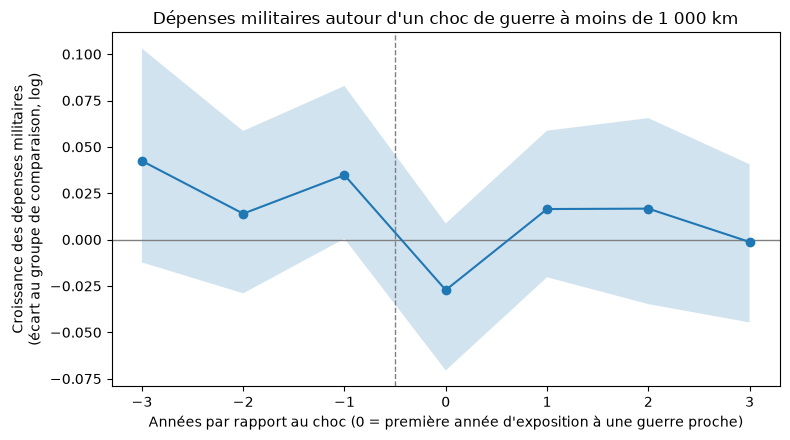

In [39]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="grey", lw=1)
ax.axvline(-0.5, color="grey", ls="--", lw=1)
ax.plot(main.index, main["moyenne"], marker="o")
ax.fill_between(main.index, main["ic_bas"], main["ic_haut"], alpha=0.2)
ax.set_xlabel("Années par rapport au choc (0 = première année d'exposition à une guerre proche)")
ax.set_ylabel("Croissance des dépenses militaires\n(écart au groupe de comparaison, log)")
ax.set_title("Dépenses militaires autour d'un choc de guerre à moins de 1 000 km")
fig.tight_layout()
fig.savefig(FIGURES / "event_study_principal.png", dpi=200)
plt.show()

panel.to_csv(PROCESSED / "panel_pays_annee.csv", index=False)



 ### Tableau récapitulatif par épisode (avant / après)

In [40]:
ep_tab = (es[es["k"].isin([-3, -2, -1, 1, 2, 3])]
          .assign(phase=lambda d: np.where(d["k"] < 0, "avant", "apres"))
          .groupby(["episode", "phase"])["excess_w"].mean().unstack())
ep_tab["diff"] = ep_tab["apres"] - ep_tab["avant"]
ep_tab["n_pays"] = es.groupby("episode")["gwno"].nunique()
ep_tab["guerre"] = [loc_name.get(int(float(e.split("_")[1])), "?") for e in ep_tab.index]

print(ep_tab.sort_values("n_pays", ascending=False).round(3).to_string())
print("\nÉpisodes avec diff > 0 :", int((ep_tab["diff"] > 0).sum()), "sur", len(ep_tab))



phase       apres  avant   diff  n_pays                                                     guerre
episode                                                                                           
2003_420    0.106  0.007  0.099       9  Australia, Iraq, United Kingdom, United States of America
2014_13246  0.098 -0.012  0.110       8                                                    Ukraine
2022_13243  0.070  0.031  0.039       8                             Russia (Soviet Union), Ukraine
1995_401    0.084  0.121 -0.037       6                                      Russia (Soviet Union)
2013_259   -0.028 -0.007 -0.021       5                                                       Iraq
2013_297   -0.011  0.101 -0.112       5                                                    Nigeria
1995_382    0.067 -0.109  0.176       4                                               Sierra Leone
2013_283   -0.073 -0.014 -0.059       3                                           DR Congo (Zaire)
2009_374  

 ## 11. Tests de robustesse



 On recalcule l'écart de croissance post- moins pré-choc (moyenne de k=1..3 moins moyenne de k=-3..-1,

 avec IC à 95 % par bootstrap) selon plusieurs variantes : unité de vote (épisode / pays-choc), définition

 du choc, exclusion ou non de certains pays.



In [41]:
resultats = []

def did_stat(df, col="excess_w", n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    groups = {e: g for e, g in df.groupby("episode")}
    eps = list(groups)
    def stat(d):
        m = d.groupby("k")[col].mean()
        return m.reindex([1, 2, 3]).mean() - m.reindex([-3, -2, -1]).mean()
    point = stat(df)
    boots = [stat(pd.concat([groups[e] for e in rng.choice(eps, size=len(eps), replace=True)]))
             for _ in range(n_boot)]
    return point, np.quantile(boots, 0.025), np.quantile(boots, 0.975)

def stack_events(shock_col, clean_col, drop=(), last_year=2022, col="excess_w"):
    ev_ = panel[(panel[shock_col] == 1) & (panel[clean_col] == 1) & (panel["year"] <= last_year)
                & (~panel["country"].isin(drop))][["gwno", "year"]].copy()
    idx_ = panel.set_index(["gwno", "year"])
    rows_ = []
    for e in ev_.itertuples():
        for k in range(-3, 4):
            key = (e.gwno, e.year + k)
            if key in idx_.index:
                rows_.append((e.year, k, idx_.loc[key, col]))
    d = pd.DataFrame(rows_, columns=["episode", "k", col]).dropna()
    d = d.groupby(["episode", "k"])[col].mean().reset_index()   # un cluster-année = un vote
    return len(ev_), d

def ajouter(nom, n, df, col="excess_w"):
    p, lo_, hi_ = did_stat(df, col)
    resultats.append((nom, n, df["episode"].nunique(), round(p, 3), round(lo_, 3), round(hi_, 3)))

# Famille A : un épisode (année x guerre) = un vote
ajouter("A. PRINCIPAL (un épisode = un vote)", len(ev), ep_k)
ajouter("A. Croissance brute (sans winsorisation)", len(ev), ep_k, "excess_raw")
ajouter("A. Un pays-choc = un vote", len(ev), es)

# Famille B : un cluster-année = un vote (variantes comparables entre elles)
for nom, sc, cc, drop in [
    ("B. Règle principale, regroupement par année", "shock_war_1000", "clean_prim", ()),
    ("B. Sans la Biélorussie", "shock_war_1000", "clean_prim", ("Belarus",)),
    ("B. Règle 'aucune implication'", "shock_war_1000", "clean_any", ()),
    ("B. Choc à l'entrée en exposition (tout conflit)", "shock_1000", "clean_prim", ()),
]:
    n, d = stack_events(sc, cc, drop)
    ajouter(nom, n, d)

print(pd.DataFrame(resultats, columns=["variante", "chocs", "clusters", "ecart_post_pre", "ic_bas", "ic_haut"]
                    ).to_string(index=False))
print("\nÉpisodes avec écart positif :", int((ep_tab["diff"] > 0).sum()), "sur", int(ep_tab["diff"].notna().sum()))



                                       variante  chocs  clusters  ecart_post_pre  ic_bas  ic_haut
            A. PRINCIPAL (un épisode = un vote)     79        28          -0.020  -0.060    0.020
       A. Croissance brute (sans winsorisation)     79        28          -0.024  -0.072    0.019
                      A. Un pays-choc = un vote     79        28           0.021  -0.024    0.054
    B. Règle principale, regroupement par année     79        14          -0.009  -0.064    0.039
                         B. Sans la Biélorussie     76        14          -0.007  -0.064    0.043
                  B. Règle 'aucune implication'     51        13          -0.008  -0.077    0.042
B. Choc à l'entrée en exposition (tout conflit)     55        20           0.001  -0.033    0.030

Épisodes avec écart positif : 11 sur 25


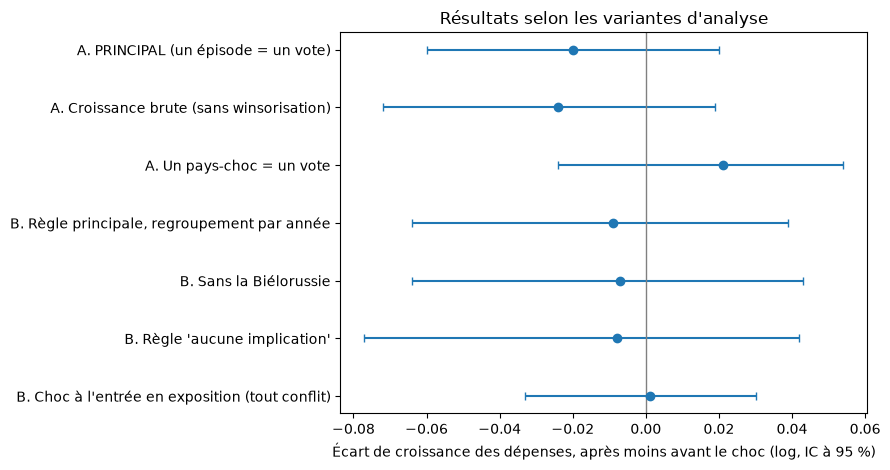

In [42]:
res = pd.DataFrame(resultats, columns=["variante", "chocs", "clusters", "ecart_post_pre", "ic_bas", "ic_haut"])
res.to_csv(PROCESSED / "resultats_robustesse.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(res))[::-1]
ax.errorbar(res["ecart_post_pre"], y,
            xerr=[res["ecart_post_pre"] - res["ic_bas"], res["ic_haut"] - res["ecart_post_pre"]],
            fmt="o", capsize=3)
ax.axvline(0, color="grey", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(res["variante"])
ax.set_xlabel("Écart de croissance des dépenses, après moins avant le choc (log, IC à 95 %)")
ax.set_title("Résultats selon les variantes d'analyse")
fig.tight_layout()
fig.savefig(FIGURES / "robustesse_variantes.png", dpi=200)
plt.show()



 ## 12. Tableau récapitulatif des épisodes (figure)



 Mise en forme du tableau par épisode pour publication : uniquement les épisodes touchant au moins 3 pays,

 avec les exemples de pays concernés et l'écart de croissance en points de pourcentage.



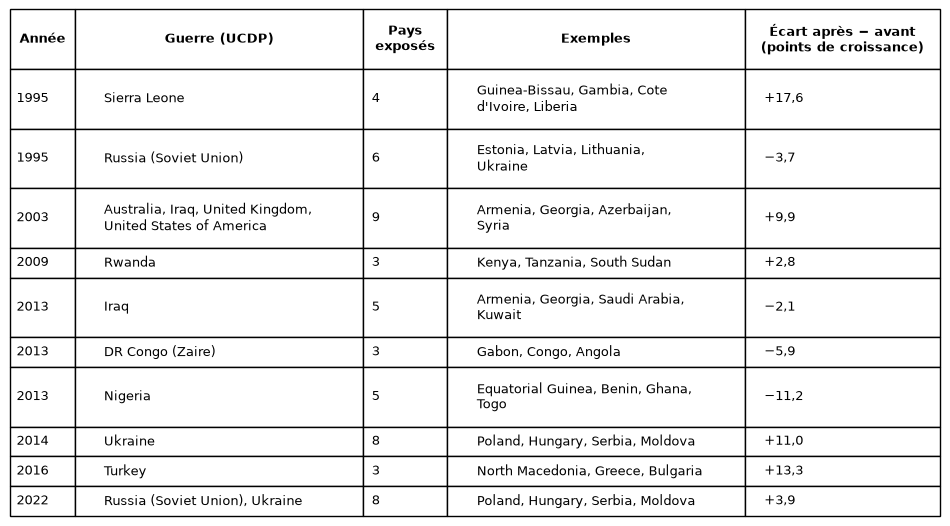

In [43]:
# 1. Table complète : combinaison de ep_tab (statistiques par épisode) et ep (exemples de pays)
full = ep_tab.reset_index().copy()
full["year"] = full["episode"].apply(lambda e: int(e.split("_")[0]))
full["conflict_id"] = full["episode"].apply(lambda e: int(float(e.split("_")[1])))
full = full.merge(ep[["year", "conflict_id", "exemples"]], on=["year", "conflict_id"], how="left")
full["ecart_pts"] = full["diff"] * 100
full["guerre_ucdp"] = full["guerre"]

# 2. Sélection des colonnes utiles, filtrage des épisodes avec au moins 3 pays
cols = ["year", "guerre_ucdp", "n_pays", "exemples", "ecart_pts"]
show = full.loc[full["n_pays"] >= 3, cols].copy()

# 3. Nettoyage des noms de pays et mise en forme du texte pour l'affichage
noms = {"Gambia, The": "Gambia", "Congo, Republic": "Congo", "Congo, DR": "DR Congo"}

def nettoyer(s):
    if not isinstance(s, str):
        return s
    for k, v in noms.items():
        s = s.replace(k, v)
    return s

show["exemples"] = show["exemples"].map(nettoyer)
show["ecart_pts"] = show["ecart_pts"].map(lambda v: f"{v:+.1f}".replace(".", ",").replace("-", "−"))
show["guerre_ucdp"] = show["guerre_ucdp"].map(lambda s: textwrap.fill(str(s), 36))
show["exemples"] = show["exemples"].map(lambda s: textwrap.fill(str(s), 34))
show.columns = ["Année", "Guerre (UCDP)", "Pays\nexposés", "Exemples", "Écart après − avant\n(points de croissance)"]

# 4. Mise en page du tableau et export en image
cell = show.astype(str).values.tolist()
head = list(show.columns)
nl = [max(str(x).count("\n") + 1 for x in r) for r in ([head] + cell)]

fig, ax = plt.subplots(figsize=(12, 0.34 * sum(nl) + 0.8))
ax.axis("off")
tb = ax.table(cellText=cell, colLabels=head, cellLoc="left", bbox=[0, 0, 1, 1],
              colWidths=[0.07, 0.31, 0.09, 0.32, 0.21])
tb.auto_set_font_size(False)
tb.set_fontsize(9)
for (i, j), c in tb.get_celld().items():
    c.set_height(nl[i] / sum(nl))
    if i == 0:
        c.set_text_props(weight="bold")

fig.savefig(FIGURES / "tableau_episodes.png", dpi=200, bbox_inches="tight")
plt.show()



 ## 13. Comparaison avec des annonces officielles de hausse des dépenses (2025)



 Contrôle de cohérence : comparaison de la croissance 2025 calculée à partir des données SIPRI avec des

 chiffres annoncés publiquement pour quelques pays. **Les valeurs du dictionnaire `attendu` sont saisies à

 la main** (par exemple depuis des annonces de presse ou des communiqués officiels) : à vérifier / sourcer

 si ce contrôle doit être documenté ou publié tel quel.



In [44]:
attendu = {"Poland": 0.23, "Germany": 0.24, "Spain": 0.50, "Belgium": 0.59,
           "France": 0.015, "United Kingdom": -0.02, "Ukraine": 0.20}

chk = panel[(panel["year"] == 2025) & panel["country"].isin(attendu)][["country", "dlog_milex"]].copy()
chk["nos_donnees_%"] = ((np.exp(chk["dlog_milex"]) - 1) * 100).round(1)
chk["annonce_%"] = chk["country"].map(lambda c: round(attendu[c] * 100, 1))
print(chk[["country", "nos_donnees_%", "annonce_%"]].to_string(index=False))



       country  nos_donnees_%  annonce_%
United Kingdom           -2.0       -2.0
       Belgium           58.7       59.0
        France            1.5        1.5
         Spain           49.6       50.0
       Germany           23.9       24.0
        Poland           23.4       23.0
       Ukraine           19.7       20.0


 ## 14. Carte : exposition géographique au choc ukrainien (2022)



 Carte centrée sur Kiev avec un rayon de 1 000 km, distinguant les belligérants directs, les pays exposés

 (au sens de la section 7) et les autres, avec les capitales situées juste autour du seuil de 1 000 km.



In [45]:
kiev_lat, kiev_lon = snap.loc[snap["gwcode"] == 369, ["caplat", "caplong"]].iloc[0]
crs_proj = f"+proj=aeqd +lat_0={kiev_lat} +lon_0={kiev_lon} +datum=WGS84 +units=m +no_defs"

gdf = snap.to_crs(crs_proj)
kiev_pt = gpd.GeoSeries([Point(kiev_lon, kiev_lat)], crs="EPSG:4326").to_crs(crs_proj)
buffer_1000km = kiev_pt.buffer(1000 * 1000, resolution=64)

exposed_codes = set(panel.loc[(panel["year"] == 2022) & (panel["exp_war_1000"] == 1)
                               & (panel["clean_prim"] == 1), "gwno"])
direct_codes = {365, 369}

def attribuer_statut(code):
    if code in direct_codes:
        return "Belligérant direct"
    elif code in exposed_codes:
        return "Pays exposé (≤ 1 000 km)"
    return "Autre"

gdf["status"] = gdf["gwcode"].map(attribuer_statut)

def fr(x):
    return f"{x:,.0f}".replace(",", " ")

caps = snap[["gwcode", "cntry_name", "caplong", "caplat"]].copy()
caps["d_kiev"] = caps["gwcode"].map(lambda g: capdist.at[g, 369])
proches = caps[caps["d_kiev"].between(950, 1100) & ~caps["gwcode"].isin(direct_codes)]
print(proches[["cntry_name", "d_kiev"]].sort_values("d_kiev").round(0).to_string(index=False))
pts = gpd.GeoDataFrame(proches, geometry=gpd.points_from_xy(proches["caplong"], proches["caplat"]),
                        crs="EPSG:4326").to_crs(crs_proj)



cntry_name  d_kiev
    Serbia   977.0
  Slovakia  1003.0
  Bulgaria  1022.0
   Austria  1054.0
   Estonia  1066.0


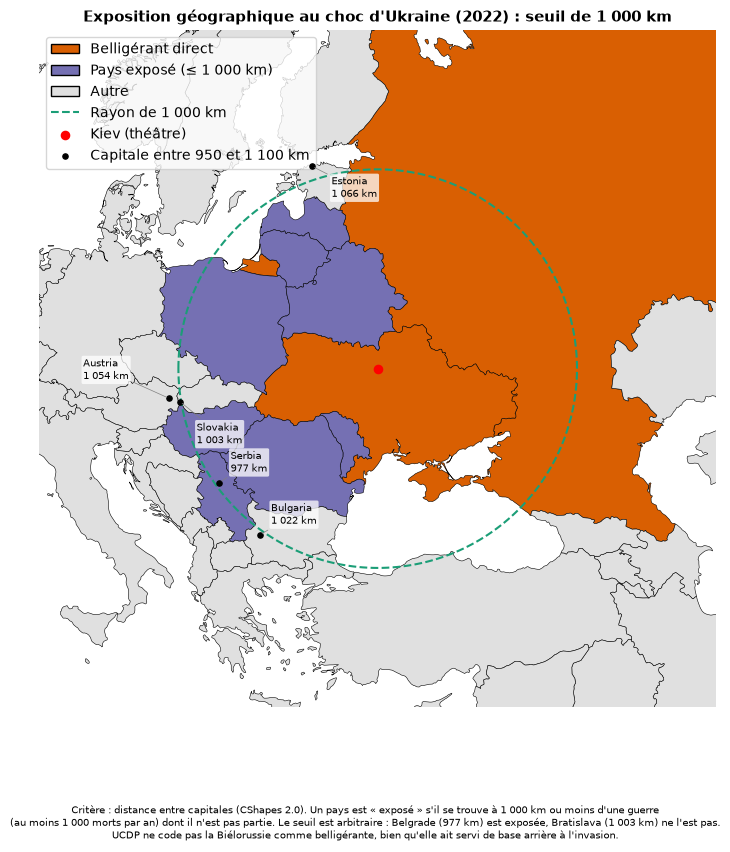

In [46]:
fig, ax = plt.subplots(figsize=(10, 8.8))
couleurs = {"Belligérant direct": "#d95f02", "Pays exposé (≤ 1 000 km)": "#7570b3", "Autre": "#e0e0e0"}
for statut, col in couleurs.items():
    sub = gdf[gdf["status"] == statut]
    if not sub.empty:
        sub.plot(ax=ax, color=col, edgecolor="black", linewidth=0.4)

buffer_1000km.boundary.plot(ax=ax, color="#1b9e77", linestyle="--", linewidth=1.5, label="Rayon de 1 000 km")
kiev_pt.plot(ax=ax, color="red", markersize=35, zorder=5, label="Kiev (théâtre)")
pts.plot(ax=ax, color="black", markersize=14, zorder=6, label="Capitale entre 950 et 1 100 km")
decalages_carte = {"Austria": (-62, 14), "Slovakia": (12, -30), "Estonia": (14, -22)}   # (dx, dy) en points ; défaut (8, 8)
for _, r in pts.iterrows():
    dx, dy = decalages_carte.get(r["cntry_name"], (8, 8))
    ax.annotate(f"{r['cntry_name']}\n{fr(r['d_kiev'])} km", (r.geometry.x, r.geometry.y),
                xytext=(dx, dy), textcoords="offset points", fontsize=7.5, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

bounds = buffer_1000km.total_bounds
marge = 700000
ax.set_xlim([bounds[0] - marge, bounds[2] + marge])
ax.set_ylim([bounds[1] - marge, bounds[3] + marge])
ax.axis("off")
handles, _ = ax.get_legend_handles_labels()
handles = [Patch(facecolor=c, edgecolor="black", label=t) for t, c in couleurs.items()] + handles
ax.legend(handles=handles, loc="upper left", frameon=True)
ax.set_title("Exposition géographique au choc d'Ukraine (2022) : seuil de 1 000 km", fontsize=11, weight="bold")

d_serbie, d_slovaquie = capdist.at[340, 369], capdist.at[317, 369]
legende = ("Critère : distance entre capitales (CShapes 2.0). Un pays est « exposé » s'il se trouve à 1 000 km ou moins d'une guerre\n"
           "(au moins 1 000 morts par an) dont il n'est pas partie. Le seuil est arbitraire : "
           f"Belgrade ({fr(d_serbie)} km) est exposée, Bratislava ({fr(d_slovaquie)} km) ne l'est pas.\n"
           "UCDP ne code pas la Biélorussie comme belligérante, bien qu'elle ait servi de base arrière à l'invasion.")
fig.text(0.5, 0.0, legende, ha="center", va="top", fontsize=7.5)

fig.savefig(FIGURES / "carte_choc_ukraine_2022.png", dpi=200, bbox_inches="tight")
plt.show()



 ## 15. Distance à la guerre et croissance des dépenses militaires (2022)



 Relation, en coupe transversale sur 2022, entre la distance à la guerre la plus proche et l'écart de

 croissance des dépenses par rapport au groupe de comparaison, par tranche de distance (médiane et IC à

 95 % par bootstrap) et par corrélation de rang (Spearman).



In [47]:
sc = panel[(panel["year"] == 2022) & (panel["own_primary"] == 0)
           & panel["d_war"].notna() & panel["excess_w"].notna()].copy()
sc["exces_pts"] = sc["excess_w"] * 100

etiq = ["< 1 000 km", "1 000–2 000 km", "2 000–4 000 km", "> 4 000 km"]
sc["tranche"] = pd.cut(sc["d_war"], bins=[0, 1000, 2000, 4000, np.inf], labels=etiq, right=False)

rng = np.random.default_rng(42)

def mediane_ic(v, n_boot=1000):
    v = v.to_numpy()
    meds = [np.median(rng.choice(v, size=len(v), replace=True)) for _ in range(n_boot)]
    return np.median(v), np.quantile(meds, 0.025), np.quantile(meds, 0.975)

lignes = []
for t, g in sc.groupby("tranche", observed=True):
    m, lo_, hi_ = mediane_ic(g["exces_pts"])
    lignes.append((t, len(g), m, lo_, hi_))
tranches = pd.DataFrame(lignes, columns=["tranche", "n", "mediane", "ic_bas", "ic_haut"]).set_index("tranche")
print(tranches.round(1).to_string())

rho = sc["d_war"].corr(sc["exces_pts"], method="spearman")
rhos = []
for s in rng.integers(0, 1_000_000_000, size=1000):
    b = sc.sample(len(sc), replace=True, random_state=int(s))
    rhos.append(b["d_war"].corr(b["exces_pts"], method="spearman"))
rho_lo, rho_hi = np.quantile(rhos, [0.025, 0.975])
print(f"Spearman : {rho:.3f} (IC 95 % : {rho_lo:.3f} ; {rho_hi:.3f}) | n = {len(sc)}")



                 n  mediane  ic_bas  ic_haut
tranche                                     
< 1 000 km      15     -1.6   -13.0      2.0
1 000–2 000 km  44      2.1    -1.5      5.0
2 000–4 000 km  29     -3.4    -5.8      0.3
> 4 000 km      27     -2.0    -4.5      0.8
Spearman : -0.085 (IC 95 % : -0.273 ; 0.111) | n = 115


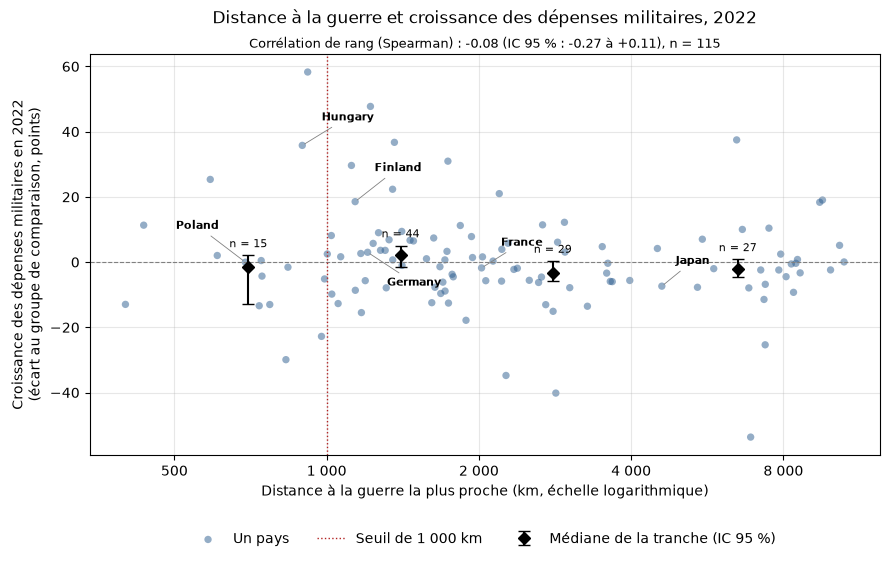

In [48]:
centres = {"< 1 000 km": 700, "1 000–2 000 km": 1400, "2 000–4 000 km": 2800, "> 4 000 km": 6500}
fig, ax = plt.subplots(figsize=(9, 5.8))
ax.scatter(sc["d_war"], sc["exces_pts"], s=28, alpha=0.5, color="#2b5c8f", edgecolors="none", label="Un pays")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.axvline(1000, color="firebrick", lw=1, ls=":", label="Seuil de 1 000 km")
for i, (t, r) in enumerate(tranches.iterrows()):
    ax.errorbar(centres[t], r["mediane"], yerr=[[r["mediane"] - r["ic_bas"]], [r["ic_haut"] - r["mediane"]]],
                fmt="D", color="black", capsize=4, markersize=6, zorder=5,
                label="Médiane de la tranche (IC 95 %)" if i == 0 else None)
    ax.annotate(f"n = {int(r['n'])}", (centres[t], r["ic_haut"]), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=8)
ax.set_xscale("log")
ax.set_xticks([500, 1000, 2000, 4000, 8000])
ax.set_xticklabels(["500", "1 000", "2 000", "4 000", "8 000"])
ax.minorticks_off()

decalages = {"Poland": (-50, 24), "Finland": (14, 22), "Germany": (14, -24),
             "France": (14, 16), "Japan": (10, 16), "Hungary": (14, 18)}
for pays, off in decalages.items():
    r = sc[sc["country"] == pays]
    if len(r):
        ax.annotate(pays, (r["d_war"].iloc[0], r["exces_pts"].iloc[0]), xytext=off, textcoords="offset points",
                    fontsize=8, weight="bold", arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))

ax.text(0.5, 1.015, f"Corrélation de rang (Spearman) : {rho:+.2f} (IC 95 % : {rho_lo:+.2f} à {rho_hi:+.2f}), n = {len(sc)}",
        transform=ax.transAxes, ha="center", fontsize=9)
ax.set_xlabel("Distance à la guerre la plus proche (km, échelle logarithmique)")
ax.set_ylabel("Croissance des dépenses militaires en 2022\n(écart au groupe de comparaison, points)")
ax.set_title("Distance à la guerre et croissance des dépenses militaires, 2022", pad=22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "scatter_distance_vs_croissance_2022.png", dpi=200)
plt.show()



